In [ ]:
# optional if you have trouble running the environments
# import sys
# sys.path.insert(0, "../src")

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from remy.paths import PROJECT_ROOT

DATA = PROJECT_ROOT / "data" / "raw"

## Initial Look

Load datasets, get shapes, datatypes, missing value counts

In [3]:
recipes = pd.read_parquet(DATA / "recipes.parquet")
interactions = pd.read_parquet(DATA / "interactions.parquet")
print("Recipes:", recipes.shape, "Interactions:", interactions.shape)
print("Sample Recipes:")
recipes.head()

Recipes: (231637, 12) Interactions: (1132367, 5)
Sample Recipes:


,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"[60-minutes-or-less, time-to-make, course, mai...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"[make a choice and proceed with recipe, depend...",autumn is my favorite time of year to cook! th...,"[winter squash, mexican seasoning, mixed spice...",7
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"[30-minutes-or-less, time-to-make, course, mai...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"[preheat oven to 425 degrees f, press dough in...",this recipe calls for the crust to be prebaked...,"[prepared pizza crust, sausage patty, eggs, mi...",6
2,all in the kitchen chili,112140,130,196586,2005-02-25,"[time-to-make, course, preparation, main-dish,...","[269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]",6,"[brown ground beef in large pot, add chopped o...",this modified version of 'mom's' chili was a h...,"[ground beef, yellow onions, diced tomatoes, t...",13
3,alouette potatoes,59389,45,68585,2003-04-14,"[60-minutes-or-less, time-to-make, course, mai...","[368.1, 17.0, 10.0, 2.0, 14.0, 8.0, 20.0]",11,[place potatoes in a large pot of lightly salt...,"this is a super easy, great tasting, make ahea...","[spreadable cheese with garlic and herbs, new ...",11
4,amish tomato ketchup for canning,44061,190,41706,2002-10-25,"[weeknight, time-to-make, course, main-ingredi...","[352.9, 1.0, 337.0, 23.0, 3.0, 0.0, 28.0]",5,"[mix all ingredients& boil for 2 1 / 2 hours ,...",my dh's amish mother raised him on this recipe...,"[tomato juice, apple cider vinegar, sugar, sal...",8


In [4]:
for name, frame in [("recipes", recipes), ("interactions", interactions)]:
    print(name)
    display(pd.DataFrame({"dtype": frame.dtypes.astype(str), "missing": frame.isna().sum()}))
    print("Memory (MiB):", round(frame.memory_usage(deep=True).sum() / 1024**2, 2))

recipes


,dtype,missing
name,string,0
id,int64,0
minutes,int32,0
contributor_id,int64,0
submitted,datetime64[ns],0
tags,object,0
nutrition,object,0
n_steps,int16,0
steps,object,0
description,string,0


Memory (MiB): 185.41
interactions


,dtype,missing
user_id,int64,0
recipe_id,int64,0
date,datetime64[ns],0
rating,int8,0
review,string,0


Memory (MiB): 382.71


## Identifiers and duplicate rows

Repeated user–recipe pairs may represent repeat interactions; investigate before removing them.

In [5]:
print("Duplicate recipe IDs:", recipes["id"].duplicated().sum())
print("Repeated user-recipe pairs:", interactions.duplicated(["user_id", "recipe_id"]).sum())
print("Duplicate rows in selected interaction columns:", interactions.duplicated().sum())
print("Unmatched recipe references:", (~interactions["recipe_id"].isin(recipes["id"])).sum())

Duplicate recipe IDs: 0
Repeated user-recipe pairs: 0
Duplicate rows in selected interaction columns: 0
Unmatched recipe references: 0


## Ratings

Inspect zero ratings and missing values. Do not automatically treat zero as dislike.

rating
0     60847
1     12818
2     14123
3     40855
4    187360
5    816364
Name: count, dtype: int64

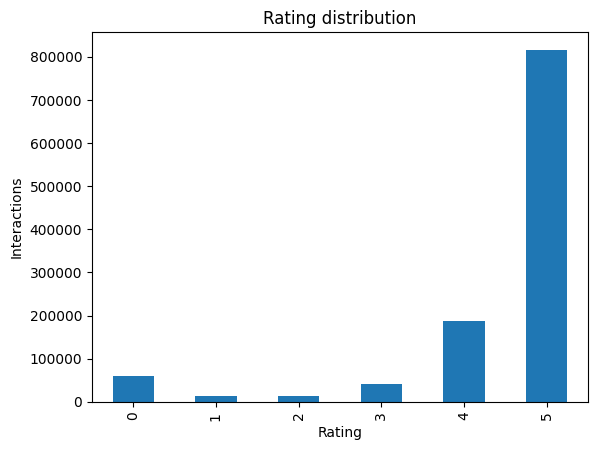

In [6]:
display(interactions["rating"].value_counts(dropna=False).sort_index())
interactions["rating"].value_counts().sort_index().plot.bar(title="Rating distribution", xlabel="Rating", ylabel="Interactions")
plt.show()

## Activity and sparsity

In [7]:
per_user = interactions.groupby("user_id").size()
per_recipe = interactions.groupby("recipe_id").size()

# Granular Percentile Breakdown (10th to 99th percentile)
percentiles = [0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
stats_df = pd.DataFrame(
    {
        "Interactions/User": per_user.quantile(percentiles),
        "Interactions/Recipe": per_recipe.quantile(percentiles),
    }
)
stats_df.index = [f"p{int(p * 100)}" for p in percentiles]

# Add mean, median, min, max
summary_rows = pd.DataFrame(
    {
        "Interactions/User": [
            per_user.min(),
            per_user.median(),
            per_user.mean(),
            per_user.max(),
        ],
        "Interactions/Recipe": [
            per_recipe.min(),
            per_recipe.median(),
            per_recipe.mean(),
            per_recipe.max(),
        ],
    },
    index=["Min", "Median (p50)", "Mean", "Max"],
)

print("=== DETAILED DISTRIBUTION METRICS ===")
display(pd.concat([summary_rows, stats_df]))

# Cold-Start / One-Hit Wonder Analysis
print("\n====== THE 'COLD-START' LONG TAIL =======")
print(f"Users with only 1 interaction:   {(per_user == 1).sum():,} ({(per_user == 1).mean():.1%})")
print(f"Users with <= 2 interactions:   {(per_user <= 2).sum():,} ({(per_user <= 2).mean():.1%})")
print(f"Recipes with only 1 review:     {(per_recipe == 1).sum():,} ({(per_recipe == 1).mean():.1%})")
print(f"Recipes with <= 2 reviews:     {(per_recipe <= 2).sum():,} ({(per_recipe <= 2).mean():.1%})")

#  Activity Buckets
print("\n=== USER ACTIVITY BUCKETS ===")
user_bins = [0, 1, 2, 5, 20, 100, np.inf]
user_labels = ["1", "2", "3-5", "6-20", "21-100", "100+"]
print(
    pd.cut(per_user, bins=user_bins, labels=user_labels)
    .value_counts(sort=False)
    .to_frame("User Count")
    .assign(Percentage=lambda df: (df["User Count"] / len(per_user) * 100).round(2))
)

print("\n=== RECIPE POPULARITY BUCKETS ===")
recipe_bins = [0, 1, 2, 5, 20, 50, np.inf]
recipe_labels = ["1", "2", "3-5", "6-20", "21-50", "50+"]
print(
    pd.cut(per_recipe, bins=recipe_bins, labels=recipe_labels)
    .value_counts(sort=False)
    .to_frame("Recipe Count")
    .assign(Percentage=lambda df: (df["Recipe Count"] / len(per_recipe) * 100).round(2))
)

=== DETAILED DISTRIBUTION METRICS ===


,Interactions/User,Interactions/Recipe
Min,1.000000,1.000000
Median (p50),1.000000,2.000000
Mean,4.997868,4.888541
Max,7671.000000,1613.000000
p10,1.000000,1.000000
p25,1.000000,1.000000
p50,1.000000,2.000000
p75,2.000000,4.000000
p90,5.000000,9.000000
p95,11.000000,15.000000



====== THE 'COLD-START' LONG TAIL =======
Users with only 1 interaction:   166,256 (73.4%)
Users with <= 2 interactions:   188,994 (83.4%)
Recipes with only 1 review:     91,953 (39.7%)
Recipes with <= 2 reviews:     137,073 (59.2%)

=== USER ACTIVITY BUCKETS ===
        User Count  Percentage
1           166256       73.38
2            22738       10.04
3-5          17911        7.91
6-20         13276        5.86
21-100        5021        2.22
100+          1368        0.60

=== RECIPE POPULARITY BUCKETS ===
       Recipe Count  Percentage
1             91953       39.70
2             45120       19.48
3-5           51680       22.31
6-20          35406       15.29
21-50          5380        2.32
50+            2098        0.91


## Dates and preparation-time extremes

In [8]:
for label, values in [("Submitted", recipes["submitted"]), ("Interaction", interactions["date"])]:
    dates = pd.to_datetime(values, errors="coerce")
    print(label, "range:", dates.min(), "to", dates.max(), "invalid/missing:", dates.isna().sum())
display(recipes[["minutes", "n_steps", "n_ingredients"]].describe(percentiles=[0.5, 0.9, 0.99]))
display(recipes.nlargest(10, "minutes"))

Submitted range: 1999-08-06 00:00:00 to 2018-12-04 00:00:00 invalid/missing: 0
Interaction range: 2000-01-25 00:00:00 to 2018-12-20 00:00:00 invalid/missing: 0


,minutes,n_steps,n_ingredients
count,2.316370e+05,231637.000000,231637.000000
mean,9.398546e+03,9.765499,9.051153
std,4.461963e+06,5.995128,3.734796
min,0.000000e+00,0.000000,1.000000
50%,4.000000e+01,9.000000,9.000000
90%,1.350000e+02,17.000000,14.000000
99%,9.039200e+02,30.000000,20.000000
max,2.147484e+09,145.000000,43.000000


,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
144074,no bake granola balls,261647,2147483647,464080,2007-10-26,"[60-minutes-or-less, time-to-make, course, pre...","[330.3, 23.0, 110.0, 4.0, 15.0, 24.0, 15.0]",9,"[preheat the oven to 350 degrees, spread oats ...",healthy snacks that kids (and grown ups) will ...,"[rolled oats, unsweetened dried shredded cocon...",8
109624,how to preserve a husband,447963,1051200,576273,2011-02-01,"[time-to-make, course, preparation, for-1-or-2...","[407.4, 57.0, 50.0, 1.0, 7.0, 115.0, 5.0]",9,"[be careful in your selection, don't choose to...","found this in a local wyoming cookbook ""a coll...","[cream, peach]",2
106563,homemade fruit liquers,291571,288000,553251,2008-03-12,"[time-to-make, course, main-ingredient, prepar...","[836.2, 0.0, 333.0, 0.0, 0.0, 0.0, 27.0]",12,"[rinse the fruit or berries , fruit must be cu...",this should be a nice easy project for those w...,"[berries, vodka, granulated sugar]",3
38116,celtic druid s honey mead meade metheglin,216215,259260,242729,2007-03-11,"[time-to-make, course, main-ingredient, cuisin...","[531.0, 0.0, 561.0, 1.0, 1.0, 0.0, 47.0]",18,"[equipement:, very large pan - to hold 12 pint...","mead, made from fermented honey, was the earli...","[gingerroot, lemons, juice and rind of, whole ...",7
106963,homemade vanilla,425681,259205,28177,2010-05-16,"[time-to-make, preparation, 5-ingredients-or-l...","[69.4, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]",9,[slice the vanilla beans length-wise and scrap...,found this recipe on tammy's blog (http://www....,"[vanilla beans, vodka]",2
155044,peach brandy,98912,216015,34146,2004-09-01,"[time-to-make, course, main-ingredient, prepar...","[3645.3, 3.0, 2040.0, 0.0, 16.0, 0.0, 173.0]",9,"[use only fully ripened , unblemished fruit, w...",posted in reply to a message board request for,"[fresh peaches, granulated sugar, honey, vodka]",4
5497,angelica liqueur,70551,201610,59064,2003-09-04,"[weeknight, time-to-make, course, cuisine, pre...","[891.8, 0.0, 906.0, 0.0, 1.0, 0.0, 76.0]",7,"[crush the fennel , aniseed , coriander seeds ...",finish off a large meal with a tiny glass of t...,"[fennel seed, anise seed, coriander seeds, clo...",7
177906,rumtopf,12931,187200,5060,2001-10-20,"[weeknight, time-to-make, course, main-ingredi...","[11510.6, 10.0, 6543.0, 2.0, 51.0, 5.0, 579.0]",16,"[in a 8 quart stockpot , combine sugar and wat...",rumtopf is a traditional german delicious frui...,"[sugar, water, golden rum, peaches, green seed...",8
170999,raspberry liqueur,172114,172810,83093,2006-06-09,"[time-to-make, course, main-ingredient, cuisin...","[91.5, 0.0, 35.0, 0.0, 0.0, 0.0, 3.0]",7,[rinse the berries & cut into small pieces or ...,if you love chambord as i do but suffer sticke...,"[fresh raspberry, vodka, fine sugar]",3
53721,cinnamon extract,153634,172800,208121,2006-01-30,"[time-to-make, course, preparation, for-large-...","[14.3, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]",5,"[put ingredients in container, combine, place ...",a no brainer.. so why didn't i think of it? ...,"[cinnamon sticks, vodka]",2
